# Customer Segmentation and Churn Prediction

This notebook analyses customer purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis.

Customers are segmented based on their purchasing patterns, and a Logistic Regression model is developed to identify customers who may be at risk of churn.

In [7]:
# Import required libraries for customer analysis and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 1. Loading Customer RFM Dataset

The customer-level RFM dataset is loaded for segmentation analysis and churn prediction.

Each customer is evaluated based on:
- Recency: How recently the customer purchased
- Frequency: How often the customer purchased
- Monetary: Total spending value

In [10]:
# Load the customer RFM analysis dataset

rfm = pd.read_csv(
    "data/cleaned/customer_rfm_analysis.csv"
)


# Display the first five records

rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score,Customer_Segment
0,12346.0,2011-01-18 10:01:00,326,1,77183.60,1,1,5,115,At Risk Customer
1,12347.0,2011-12-07 15:52:00,2,7,4310.00,5,5,5,555,VIP Customer
2,12348.0,2011-09-25 13:13:00,75,4,1797.24,2,4,4,244,Regular Customer
3,12349.0,2011-11-21 09:51:00,19,1,1757.55,4,1,4,414,Loyal Customer
4,12350.0,2011-02-02 16:01:00,310,1,334.40,1,1,2,112,At Risk Customer


### Dataset Preview

The RFM dataset contains customer-level purchase behaviour metrics.

Each record represents an individual customer and includes:
- Purchase recency
- Purchase frequency
- Total monetary value
- RFM scores
- Customer segment classification

In [13]:
# Display dataset information including column names, data types, and missing values

rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        4338 non-null   float64
 1   LastPurchaseDate  4338 non-null   object 
 2   Recency           4338 non-null   int64  
 3   Frequency         4338 non-null   int64  
 4   Monetary          4338 non-null   float64
 5   RecencyScore      4338 non-null   int64  
 6   FrequencyScore    4338 non-null   int64  
 7   MonetaryScore     4338 non-null   int64  
 8   RFM_Score         4338 non-null   int64  
 9   Customer_Segment  4338 non-null   object 
dtypes: float64(2), int64(6), object(2)
memory usage: 339.0+ KB


### Result

The RFM dataset contains **4,338 customer records** and **10 features**.

All columns contain complete information with no missing values.

The dataset includes customer purchase behaviour metrics, RFM scores, and customer segment classifications, making it suitable for churn prediction modelling.

## 2. Creating Churn Target Variable

For predictive modelling, customer segments are converted into a binary churn variable.

Customers classified as **At Risk Customer** are labelled as churn risk (`1`), while all other customer segments are labelled as non-churn (`0`).

In [17]:
# Create binary churn target variable based on customer segment

rfm["Churn"] = np.where(
    rfm["Customer_Segment"] == "At Risk Customer",
    1,
    0
)


# Display the first few churn labels

rfm[["Customer_Segment", "Churn"]].head()

,Customer_Segment,Churn
0,At Risk Customer,1
1,VIP Customer,0
2,Regular Customer,0
3,Loyal Customer,0
4,At Risk Customer,1


### Result

The customer segment information was successfully converted into a binary churn variable.

Customers classified as **At Risk Customer** were assigned a churn value of `1`, while all other customer segments were assigned a value of `0`.

This target variable will be used to train the classification model.

## 3. Feature Selection

The following RFM-based features are selected as input variables for the churn prediction model:

- Recency
- Frequency
- Monetary
- Recency Score
- Frequency Score
- Monetary Score

The churn variable is used as the prediction target.

In [21]:
# Define input features for the machine learning model

features = [
    "Recency",
    "Frequency",
    "Monetary",
    "RecencyScore",
    "FrequencyScore",
    "MonetaryScore"
]


# Separate independent variables and target variable

X = rfm[features]

y = rfm["Churn"]


# Display sample records from features and target

print(X.head())
print(y.head())

   Recency  Frequency  Monetary  RecencyScore  FrequencyScore  MonetaryScore
0      326          1  77183.60             1               1              5
1        2          7   4310.00             5               5              5
2       75          4   1797.24             2               4              4
3       19          1   1757.55             4               1              4
4      310          1    334.40             1               1              2
0    1
1    0
2    0
3    0
4    1
Name: Churn, dtype: int32


### Result

The input features and target variable were successfully prepared for machine learning.

The model will use customer purchasing behaviour metrics (RFM features) to predict whether a customer is likely to be at risk of churn.

## 4. Splitting Data into Training and Testing Sets

The dataset is divided into training and testing sets.

- The training set is used to train the Logistic Regression model.
- The testing set is used to evaluate model performance on unseen customer data.

A stratified split is applied to maintain the same churn/non-churn distribution in both datasets.

In [29]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Display the size of training and testing datasets

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (3470, 6)
Testing set: (868, 6)


print("Training set:", X_train.shape)
p### Result

The dataset was divided into training and testing sets using an 80:20 split.

- Training set: 3,470 customer records
- Testing set: 868 customer records

The stratified split ensures that both datasets maintain a similar distribution of churn and non-churn customers.rint("Testing set:", X_test.shape)

## 5. Feature Scaling

Feature scaling is applied before training the Logistic Regression model.

Standardization ensures that all input variables are placed on a similar scale, preventing features with larger numerical values from dominating the model.

In [33]:
# Initialize the StandardScaler

scaler = StandardScaler()


# Fit the scaler on training data and transform both training and testing data

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("Scaling completed!")

Scaling completed!


### Result

Feature scaling was completed successfully.

The RFM variables have been standardized and are ready for use in the Logistic Regression model.

## 6. Training the Churn Prediction Model

A Logistic Regression model is trained using the scaled RFM features.

The model learns patterns in customer purchasing behaviour to classify customers as either:
- At risk of churn
- Not at risk of churn

In [37]:
# Initialize and train the Logistic Regression model

model = LogisticRegression(
    random_state=42
)


model.fit(
    X_train_scaled,
    y_train
)


print("Model trained successfully!")

Model trained successfully!


In [39]:
# Generate churn predictions on the test dataset

y_pred = model.predict(X_test_scaled)


# Display the first 10 predictions

print(y_pred[:10])

[0 1 0 0 0 0 1 0 0 0]


### Result

The trained Logistic Regression model successfully generated churn predictions for the test dataset.

The output represents the predicted customer status:
- `1` → Customer classified as at risk of churn
- `0` → Customer classified as not at risk of churn

## 7. Model Evaluation

The model performance is evaluated using:

- Accuracy score
- Confusion matrix
- Classification report

These metrics help measure how effectively the model identifies customers at risk of churn.

In [43]:
# Calculate model accuracy

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)


# Display confusion matrix

print(confusion_matrix(y_test, y_pred))


# Display detailed classification metrics

print(classification_report(y_test, y_pred))

Accuracy: 0.9873271889400922
[[679   0]
 [ 11 178]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       679
           1       1.00      0.94      0.97       189

    accuracy                           0.99       868
   macro avg       0.99      0.97      0.98       868
weighted avg       0.99      0.99      0.99       868



### Model Evaluation Results

The Logistic Regression model achieved an accuracy of approximately **98.73%** on the test dataset.

Performance metrics:

- **Precision (Churn): 100%**
- **Recall (Churn): 94%**
- **F1-score (Churn): 97%**

The model correctly identified most customers who were classified as at risk of churn, while avoiding false churn predictions.

The recall score is particularly important for churn prediction because it measures how effectively the model identifies customers who may require retention efforts.

In [46]:
# Calculate confusion matrix for visualization

cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)

[[679   0]
 [ 11 178]]


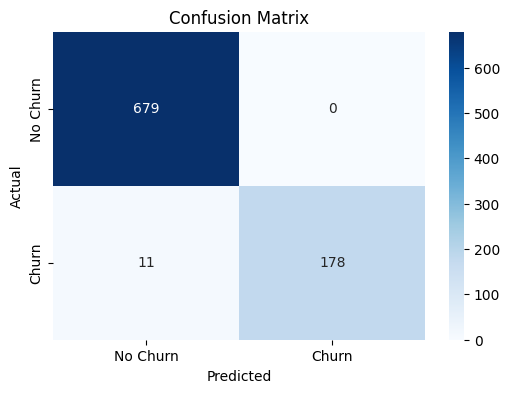

In [48]:
# Visualize confusion matrix

import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Business Insight

The confusion matrix shows that the model correctly classified:

- 679 customers as not at risk of churn
- 178 customers as at risk of churn

Only 11 at-risk customers were incorrectly classified as non-churn customers.

This indicates that the model performs well in identifying customers who may require targeted retention strategies.

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance)

          Feature  Coefficient
0         Recency     1.814762
1       Frequency     0.972162
2        Monetary     0.108274
5   MonetaryScore    -1.526067
4  FrequencyScore    -1.674651
3    RecencyScore    -8.422588


## 8. Feature Importance Analysis

The coefficients of the Logistic Regression model are analysed to understand which customer behaviour features have the strongest influence on churn prediction.

Positive coefficients indicate features associated with higher churn probability, while negative coefficients indicate features associated with lower churn probability.

In [ ]:
# Create a dataframe containing model coefficients for each feature

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})


# Sort features based on their coefficient values

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)


print(feature_importance)

### Business Insight

The model identifies **Recency** as the strongest positive indicator of churn risk.

Customers with a higher number of days since their last purchase are more likely to be classified as at risk of churn.

The negative coefficient of **RecencyScore** indicates that customers with higher recency scores (more recent purchases) are less likely to churn.

Frequency and Monetary values also contribute to identifying customer behaviour patterns, helping the model distinguish between active and potentially inactive customers.

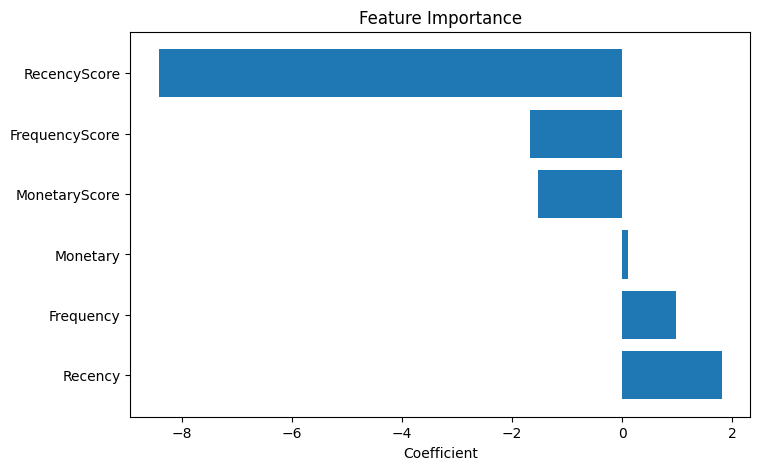

In [55]:
# Visualize feature importance based on Logistic Regression coefficients

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.xlabel("Coefficient")
plt.title("Feature Importance")
plt.show()

## 9. Conclusion

The customer segmentation and churn prediction analysis successfully identified purchasing behaviour patterns using RFM analysis.

A Logistic Regression model was developed to predict customers at risk of churn and achieved an accuracy of **98.73%**.

Key findings:

- Recency was the most influential factor in identifying churn risk.
- Customers with longer periods since their last purchase were more likely to be classified as at risk.
- The model successfully identified the majority of at-risk customers, supporting targeted customer retention strategies.
- RFM-based customer analysis can help businesses prioritize retention efforts towards valuable customers who may require re-engagement.